In [ ]:
import pandas as pd

# 1) Load Google Sheet as CSV
SHEET_ID = '1J14lbOxl6ila4Yq6ygMqF--yV43pr4Y1gFLKPQT7owo'
GID = 0
url = f'https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=csv&gid={GID}'

df = pd.read_csv(url)

In [ ]:
# 2) Convert date column (your format is dd-mm-yyyy)
df['SummaryDate'] = pd.to_datetime(df['SummaryDate'], dayfirst=True)


/tmp/ipython-input-3329939082.py:2: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



In [ ]:
# 3) Sort properly
df = df.sort_values(['Province', 'SummaryDate'])

In [ ]:
# 4) Create week number (every 7 days from earliest date)
df['Week'] = ((df['SummaryDate'] - df['SummaryDate'].min()).dt.days // 7) + 1

In [ ]:
# 5) Aggregation rules
agg_funcs = {
    'DailyTotals': 'sum',
    'TotalCases': 'sum',
    'TotalRecovered': 'sum',
    'DailyRecovered': 'sum',
    'TotalDeaths': 'sum',
    'DailyDeaths': 'sum',
    'TotalTested': 'sum',
    'DailyTested': 'sum',
    'TotalActive': 'sum',
    'DailyActive': 'sum',
    'TotalHospitalized': 'sum',
    'DailyHospitalized': 'sum',
    'TotalICU': 'sum',
    'DailyICU': 'sum'
}

In [ ]:
# 6) Group weekly (Province + Week)
df_weekly = (
    df
    .groupby(['Province', 'Abbreviation', 'Week'], as_index=False)
    .agg({**agg_funcs, 'SummaryDate': ['min', 'max']})
)

In [ ]:
# 7) Flatten columns
df_weekly.columns = (
    ['Province', 'Abbreviation', 'Week'] +
    list(agg_funcs.keys()) +
    ['StartDate', 'EndDate']
)

In [ ]:
# 8) Show first rows
df_weekly.head()

,Province,Abbreviation,Week,DailyTotals,TotalCases,TotalRecovered,DailyRecovered,TotalDeaths,DailyDeaths,TotalTested,DailyTested,TotalActive,DailyActive,TotalHospitalized,DailyHospitalized,TotalICU,DailyICU,StartDate,EndDate
0,ALBERTA,AB,1,619,8066,1795.0,327.0,135,17,434429,18425,6136.0,275.0,0,0,0,0,2020-04-01 12:00:00+00:00,2020-04-07 12:00:00+00:00
1,ALBERTA,AB,2,497,11196,5091.0,467.0,278,22,526403,15532,5827.0,8.0,630,110,201,34,2020-04-08 12:00:00+00:00,2020-04-14 12:00:00+00:00
2,ALBERTA,AB,3,1225,17919,7815.0,359.0,374,13,679140,26366,9730.0,853.0,444,-64,124,-16,2020-04-15 12:00:00+00:00,2020-04-21 12:00:00+00:00
3,ALBERTA,AB,4,1747,29405,10548.0,527.0,507,19,886641,29666,18342.0,1201.0,540,36,133,3,2020-04-22 12:00:00+00:00,2020-04-28 12:00:00+00:00
4,ALBERTA,AB,5,1043,39258,17881.0,1419.0,667,26,1097088,28334,20710.0,-402.0,615,5,145,-1,2020-04-29 12:00:00+00:00,2020-05-05 12:00:00+00:00


In [ ]:
# 9) Export weekly dataset
df_weekly.to_csv("weekly_data_output.csv", index=False)

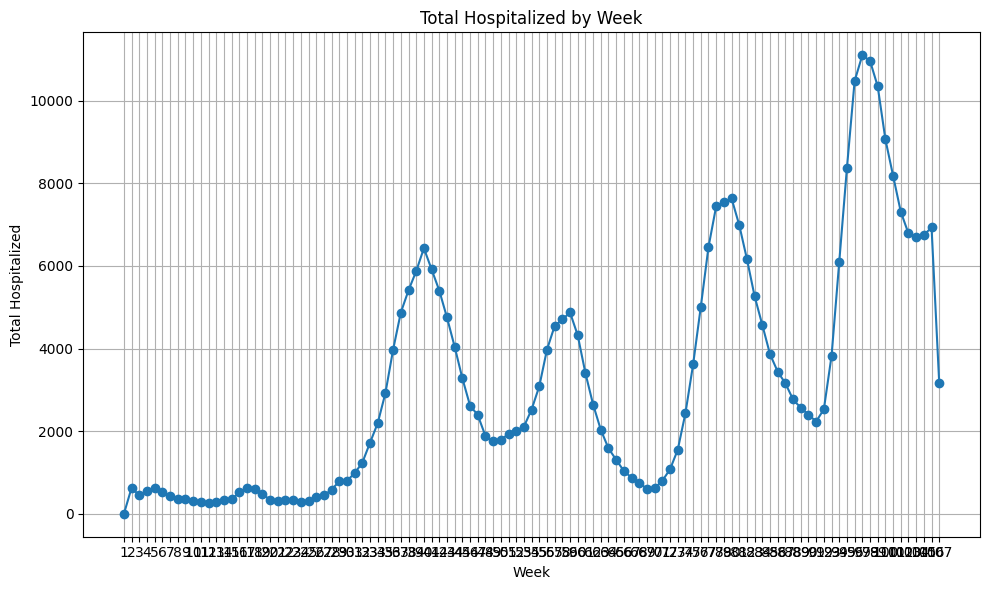

In [ ]:
import matplotlib.pyplot as plt

# If your weekly dataframe is named df_weekly:
# df_weekly = <your weekly grouped dataframe>

plt.figure(figsize=(10,6))
plt.plot(df_weekly['Week'], df_weekly['TotalHospitalized'], marker='o')

plt.title('Total Hospitalized by Week')
plt.xlabel('Week')
plt.ylabel('Total Hospitalized')

plt.grid(True)
plt.xticks(df_weekly['Week'])     # show week numbers clearly
plt.tight_layout()
plt.show()


In [ ]:
import plotly.graph_objects as go

# Create interactive plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_weekly['Week'],
    y=df_weekly['TotalHospitalized'],
    mode='lines+markers',
    name='Total Hospitalized',
    line=dict(color='green', width=2),
    marker=dict(size=8),
    hovertemplate='<b>Week %{x}</b><br>' +
                  'Total Hospitalized: %{y}<br>' +
                  '<extra></extra>'
))

fig.update_layout(
    title='Total Hospitalized by Week',
    xaxis_title='Week',
    yaxis_title='Total Hospitalized',
    hovermode='x unified',
    template='plotly_white',
    width=1000,
    height=600
)

fig.show()


In [ ]:
import plotly.graph_objects as go

# Create interactive plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_weekly['Week'],
    y=df_weekly['TotalHospitalized'],
    mode='lines+markers',
    name='Total Hospitalized',
    line=dict(color='green', width=2),
    marker=dict(size=6),
    hovertemplate='<b>Week %{x}</b><br>' +
                  'Total Hospitalized: %{y}<br>' +
                  '<extra></extra>'
))

# Add shaded region for Wave 1: weeks 20–40
fig.add_vrect(
    x0=20, x1=40,
    fillcolor="rgba(255, 99, 132, 0.15)",  # light red
    line_width=0,
    layer="below",
)

# Add shaded region for Wave 2: weeks 91–97
fig.add_vrect(
    x0=91, x1=97,
    fillcolor="rgba(255, 189, 46, 0.18)",  # light orange
    line_width=0,
    layer="below",
)

# Annotations for Wave 1
fig.add_annotation(
    x=30, y=max(df_weekly['TotalHospitalized']) * 1.05,
    text="Wave 1 focus:<br>weeks 20–40",
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=1.5,
    arrowcolor="rgba(255, 99, 132, 0.9)",
    ax=0, ay=-80,
    bgcolor="rgba(255, 255, 255, 0.9)",
    bordercolor="rgba(255, 99, 132, 0.9)",
    borderwidth=1,
    font=dict(color="rgba(220, 38, 38, 1)")
)

# Annotations for Wave 2
fig.add_annotation(
    x=94, y=max(df_weekly['TotalHospitalized']) * 1.05,
    text="Wave 2 focus:<br>weeks 91–97",
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=1.5,
    arrowcolor="rgba(234, 179, 8, 0.9)",
    ax=0, ay=-80,
    bgcolor="rgba(255, 255, 255, 0.9)",
    bordercolor="rgba(234, 179, 8, 0.9)",
    borderwidth=1,
    font=dict(color="rgba(180, 83, 9, 1)")
)

fig.update_layout(
    title='Total Hospitalized by Week',
    xaxis_title='Week',
    yaxis_title='Total Hospitalized',
    hovermode='x unified',
    template='plotly_white',
    width=1000,
    height=600,
    margin=dict(l=60, r=20, t=80, b=60)
)

fig.show()


In [ ]:
import plotly.graph_objects as go

# Create interactive plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_weekly['Week'],
    y=df_weekly['TotalHospitalized'],
    mode='lines+markers',
    name='Total Hospitalized',
    line=dict(color='blue', width=2),
    marker=dict(size=8),
    hovertemplate='<b>Week %{x}</b><br>' +
                  'Total Hospitalized: %{y}<br>' +
                  '<extra></extra>'
))

# Get y-range for rectangles
y_min = df_weekly['TotalHospitalized'].min()
y_max = df_weekly['TotalHospitalized'].max()

# Add shaded focus regions
fig.add_vrect(
    x0=20, x1=40,
    y0=y_min, y1=y_max,
    fillcolor="red", opacity=0.12,
    layer="below", line_width=0
)

fig.add_vrect(
    x0=91, x1=97,
    y0=y_min, y1=y_max,
    fillcolor="orange", opacity=0.12,
    layer="below", line_width=0
)

# Add labels for focus windows
fig.add_annotation(
    x=30, y=y_max,
    text="Focus: weeks 20–40",
    showarrow=False,
    yshift=20,
    font=dict(color="red")
)

fig.add_annotation(
    x=94, y=y_max,
    text="Focus: weeks 91–97",
    showarrow=False,
    yshift=20,
    font=dict(color="orange")
)

fig.update_layout(
    title='Total Hospitalized by Week',
    xaxis_title='Week',
    yaxis_title='Total Hospitalized',
    hovermode='x unified',
    template='plotly_white',
    width=1000,
    height=600
)

fig.show()




In [ ]:
import plotly.graph_objects as go

# Create interactive plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_weekly['Week'],
    y=df_weekly['DailyHospitalized'],
    mode='lines+markers',
    name='Daily Hospitalized',
    line=dict(color='blue', width=2),
    marker=dict(size=8),
    hovertemplate='<b>Week %{x}</b><br>' +
                  'Daily Hospitalized: %{y}<br>' +
                  '<extra></extra>'
))

fig.update_layout(
    title='Daily Hospitalized by Week',
    xaxis_title='Week',
    yaxis_title='Daily Hospitalized',
    hovermode='x unified',
    template='plotly_white',
    width=1000,
    height=600
)

fig.show()
